# 1. Preprocessing Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import (StratifiedKFold, cross_val_score)

In [ ]:
from google.colab import files
files.upload()

Saving heart (1).csv to heart (1).csv


{'heart (1).csv': b'Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease\n40,M,ATA,140,289,0,Normal,172,N,0,Up,0\n49,F,NAP,160,180,0,Normal,156,N,1,Flat,1\n37,M,ATA,130,283,0,ST,98,N,0,Up,0\n48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1\n54,M,NAP,150,195,0,Normal,122,N,0,Up,0\n39,M,NAP,120,339,0,Normal,170,N,0,Up,0\n45,F,ATA,130,237,0,Normal,170,N,0,Up,0\n54,M,ATA,110,208,0,Normal,142,N,0,Up,0\n37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1\n48,F,ATA,120,284,0,Normal,120,N,0,Up,0\n37,F,NAP,130,211,0,Normal,142,N,0,Up,0\n58,M,ATA,136,164,0,ST,99,Y,2,Flat,1\n39,M,ATA,120,204,0,Normal,145,N,0,Up,0\n49,M,ASY,140,234,0,Normal,140,Y,1,Flat,1\n42,F,NAP,115,211,0,ST,137,N,0,Up,0\n54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0\n38,M,ASY,110,196,0,Normal,166,N,0,Flat,1\n43,F,ATA,120,201,0,Normal,165,N,0,Up,0\n60,M,ASY,100,248,0,Normal,125,N,1,Flat,1\n36,M,ATA,120,267,0,Normal,160,N,3,Flat,1\n43,F,TA,100,223,0,Normal,142,N,0,Up,0\n44,M,ATA,120,1

In [ ]:
heart_failure_df = pd.read_csv('heart (1).csv')
heart_failure_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
heart_failure_df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
X = heart_failure_df.drop('HeartDisease', axis=1)
y = heart_failure_df['HeartDisease']
print(X.shape)
print(y.value_counts().sort_index())

(918, 11)
HeartDisease
0    410
1    508
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.20,
random_state=42,
stratify=y
)
print(X_train.shape, X_test.shape)

(734, 11) (184, 11)


2. Analisis LDA dan QDA

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training data:", X_train_scaled.shape)

Shape of scaled training data: (734, 15)


In [ ]:
lda_model = Pipeline([('scaler', StandardScaler()),('model', LinearDiscriminantAnalysis())])
qda_model = Pipeline([('scaler', StandardScaler()),('model', QuadraticDiscriminantAnalysis())])

In [ ]:
lda_model.fit(X_train, y_train)
qda_model.fit(X_train, y_train)
lda_pred = lda_model.predict(X_test)
qda_pred = qda_model.predict(X_test)

In [ ]:
lda_cm = confusion_matrix(y_test, lda_pred)
qda_cm = confusion_matrix(y_test, qda_pred)
print('LDA')
print(lda_cm)
print('QDA')
print(qda_cm)

LDA
[[69 13]
 [ 7 95]]
QDA
[[66 16]
 [10 92]]


In [ ]:
print('LDA REPORT')
print(classification_report(y_test, lda_pred))
print('QDA REPORT')
print(classification_report(y_test, qda_pred))

LDA REPORT
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

QDA REPORT
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        82
           1       0.85      0.90      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



3. Cross Validation LDA dan QDA (5-Fold)

In [ ]:
cv = StratifiedKFold(
n_splits=5, shuffle=True,
random_state=42)
lda_scores = cross_val_score(
lda_model, X_encoded, y, cv=cv,
scoring='accuracy')
qda_scores = cross_val_score(
qda_model, X_encoded, y, cv=cv,
scoring='accuracy')

In [ ]:
cv_lda_mean = lda_scores.mean()
cv_qda_mean = qda_scores.mean()
print('LDA Mean CV Accuracy:')
print(cv_lda_mean)
print('QDA Mean CV Accuracy:')
print(cv_qda_mean)
sdev_lda = lda_scores.std()
sdev_qda = qda_scores.std()
print('LDA Standard Deviation:')
print(sdev_lda)
print('QDA Standard Deviation:')
print(sdev_qda)

LDA Mean CV Accuracy:
0.8649263483012593
QDA Mean CV Accuracy:
0.8442444761225945
LDA Standard Deviation:
0.019280743495228316
QDA Standard Deviation:
0.021227938024205577


4. Perbandingan LDA dan QDA dengan Matriks Konfusi

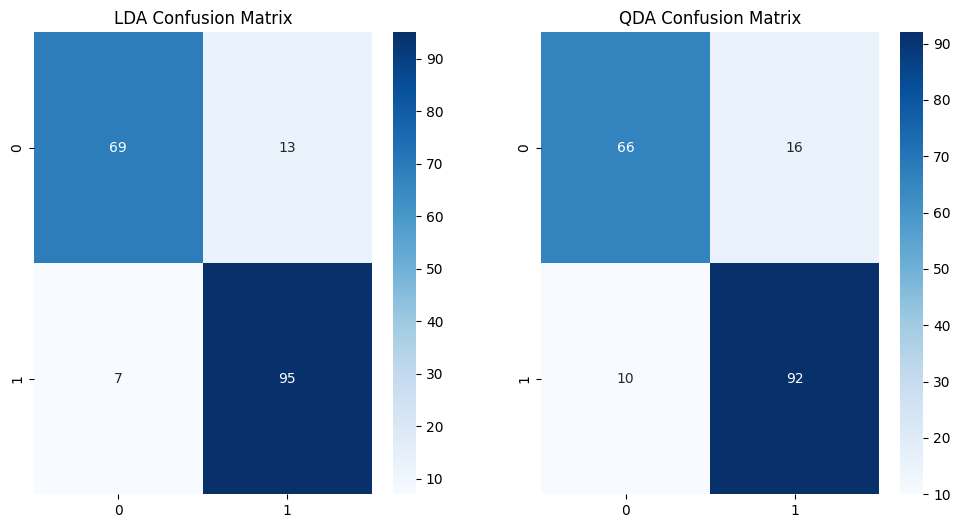

In [ ]:
# Plot Matriks Konfusi
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(lda_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
sns.heatmap(qda_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[0].set_title('LDA Confusion Matrix')
ax[1].set_title('QDA Confusion Matrix')
plt.show()